## Обзор таблицы

In [ ]:
import pandas as pd
import numpy as np
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import calendar
from pylab import rcParams
from scipy.fft import fft, fftfreq
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import optuna
import matplotlib.patches as mpatches
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score

В задании сказано: "ровно 3 листа содержащих ряды для работы, не все из них видны при открытии".
Стандартный `pd.read_excel` без `sheet_name=None` читает только первый видимый лист.
Используем `openpyxl` напрямую, чтобы увидеть все листы и их статус.

#### Меняем кодировку

In [ ]:
def decode_name(name: str) -> str:
    try:
        return name.encode('latin-1').decode('cp1251')
    except:
        return name

def decode_cell(value):
    if not isinstance(value, str):
        return value
    try:
        return value.encode('latin-1').decode('cp1251')
    except:
        return value

EXPECTED_COLS = {'temperature_2m', 'ds', 'city'}

wb = openpyxl.load_workbook('have_fun.xlsx', data_only=True)

data_sheets = []

for ws in wb.worksheets:
    old_name = ws.title
    new_name = decode_name(old_name)

    first_row = next(ws.iter_rows(max_row=1, values_only=True), ())
    col_names = {v for v in first_row if isinstance(v, str)}
    is_data_sheet = EXPECTED_COLS.issubset(col_names)
    marker = "есть данные" if is_data_sheet else "пустой лист"
    print(f"{new_name:43s}  {ws.sheet_state:10s}  {marker}")

    if is_data_sheet:
        data_sheets.append(new_name)

    if new_name != old_name:
        ws.title = new_name
        print(f"переименован {old_name}  в {new_name}")

    changed = 0
    for row in ws.iter_rows():
        for cell in row:
            decoded = decode_cell(cell.value)
            if decoded != cell.value:
                cell.value = decoded
                changed += 1
    print(f"исправлено ячеек: {changed}")

wb.save('have_fun_fixed.xlsx')
wb.close()
print(f"\nСохранено в have_fun_fixed.xlsx")
print(f"Листов с данными: {len(data_sheets)}: {data_sheets}")

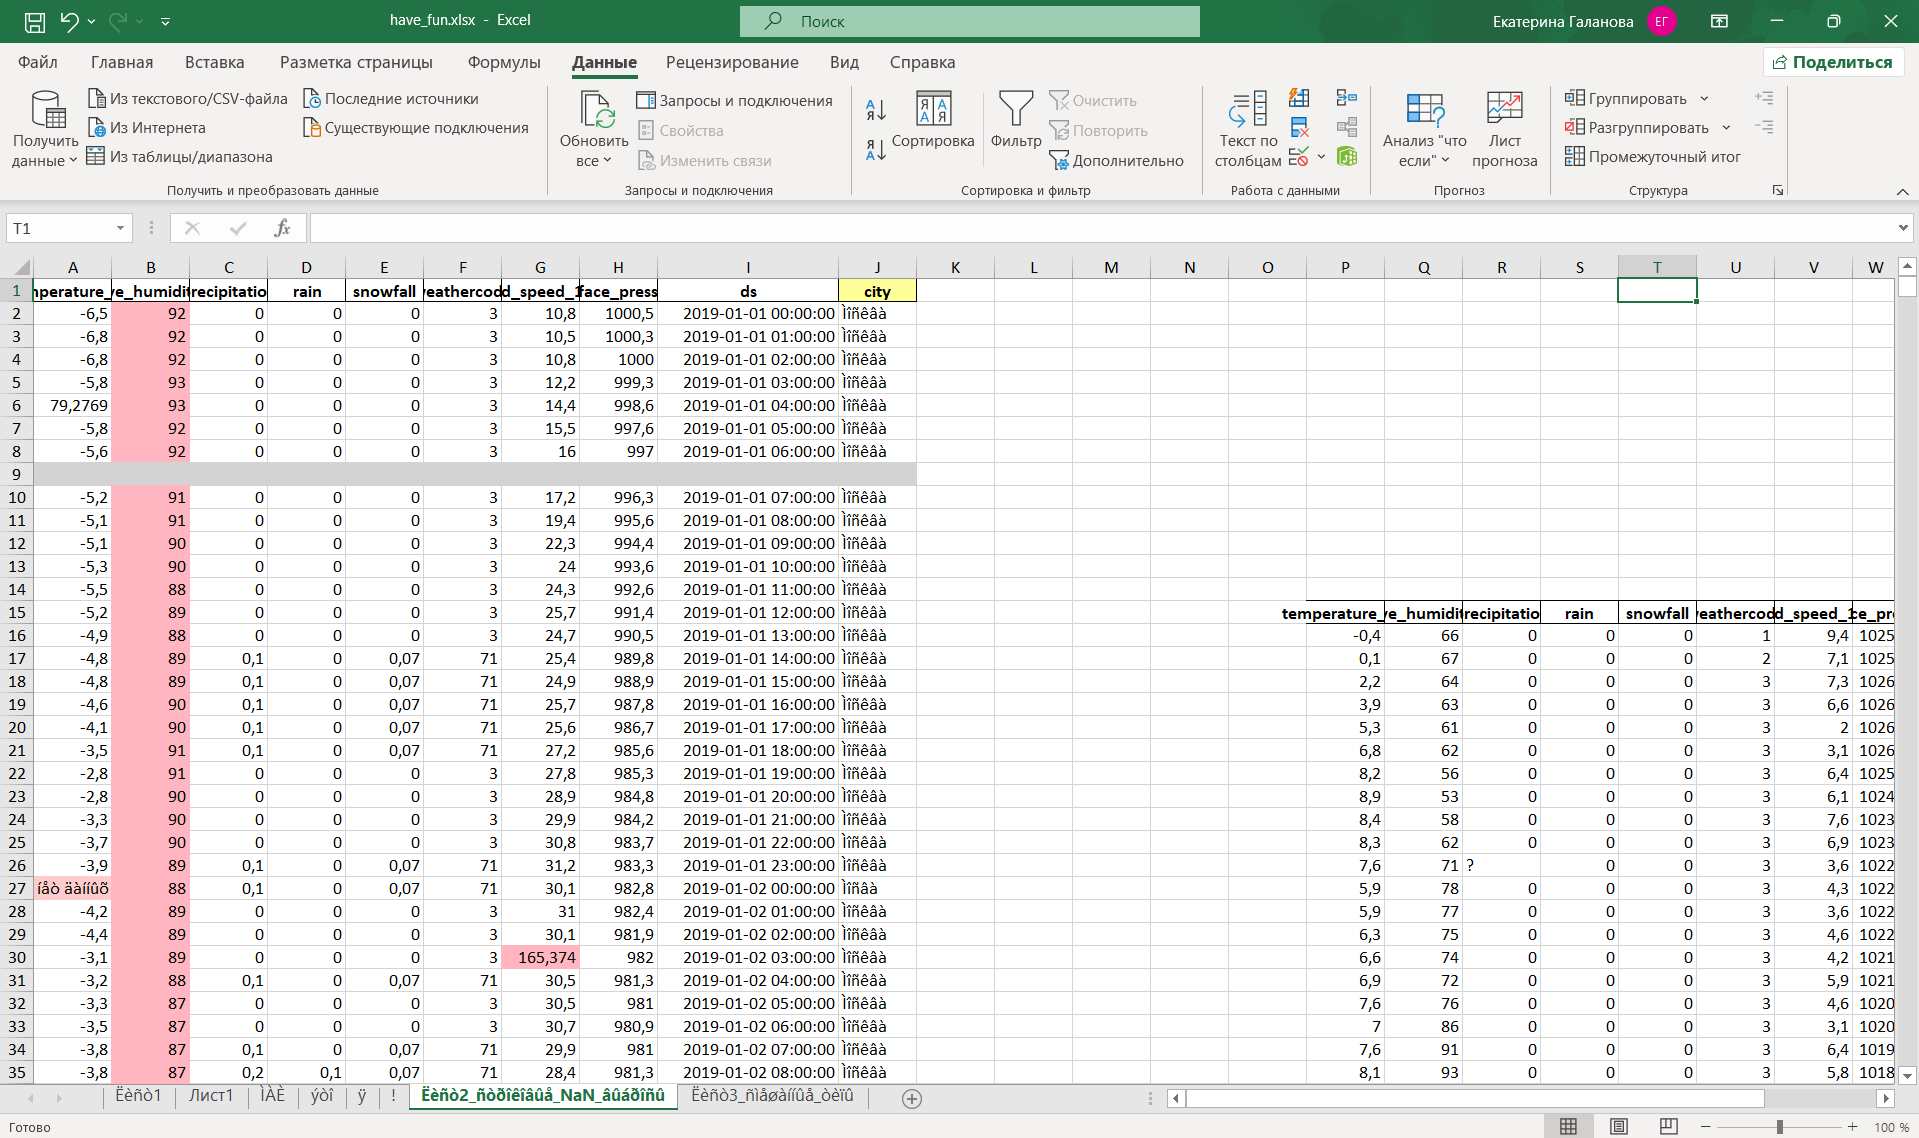

в файле можно открыть скрытые листы посмотреть на них визуально для последующей предобработки

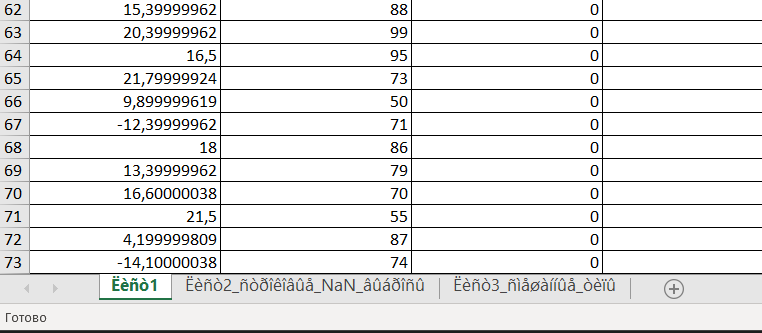

Удалила все пустые листы

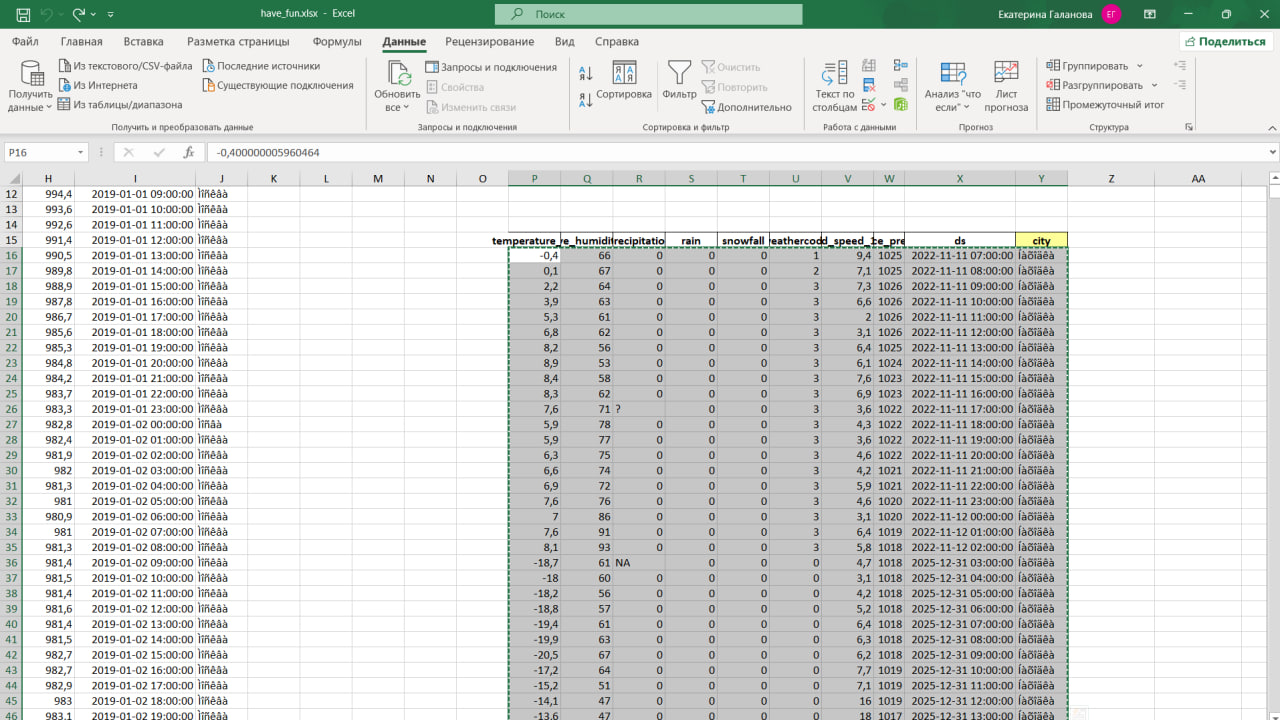

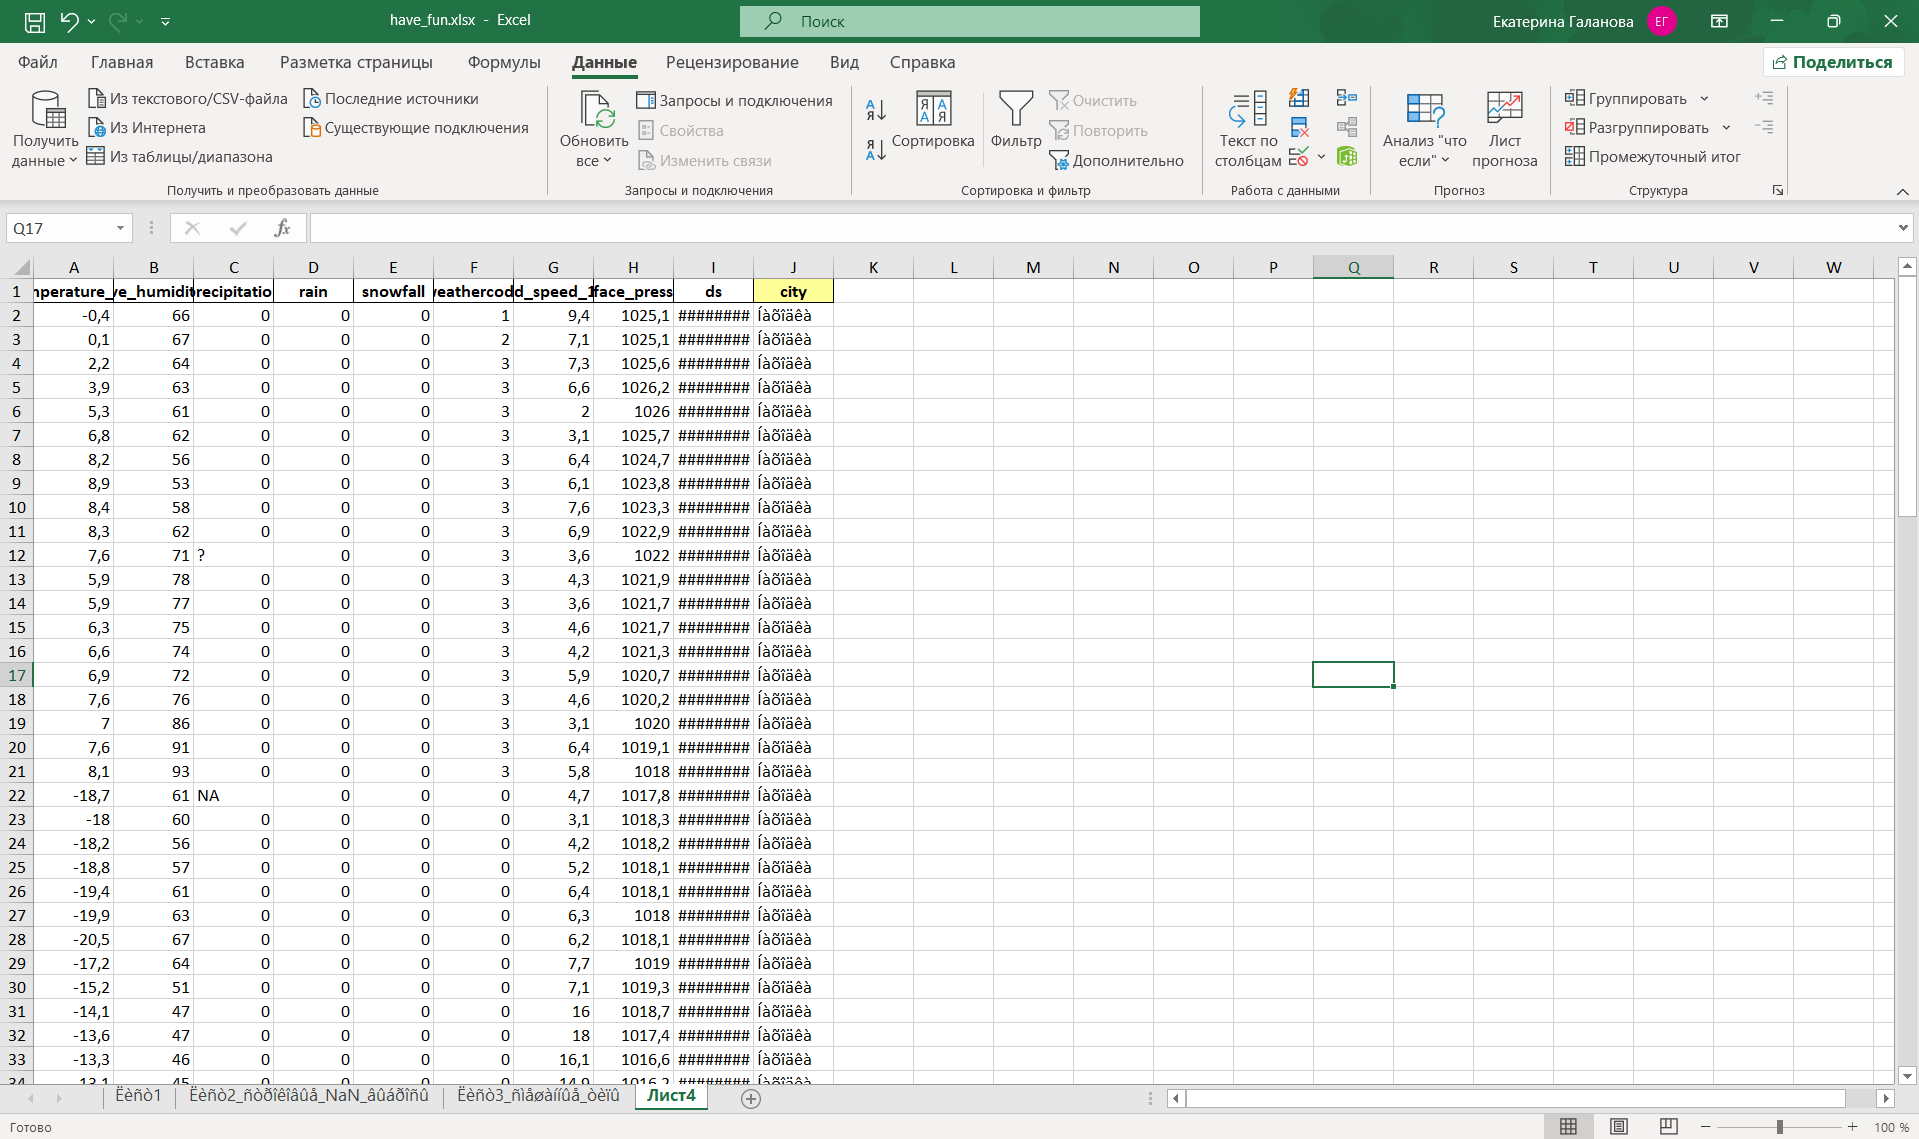

Вручную переместила строки невошедшие в общую таблицу в отдельный лист
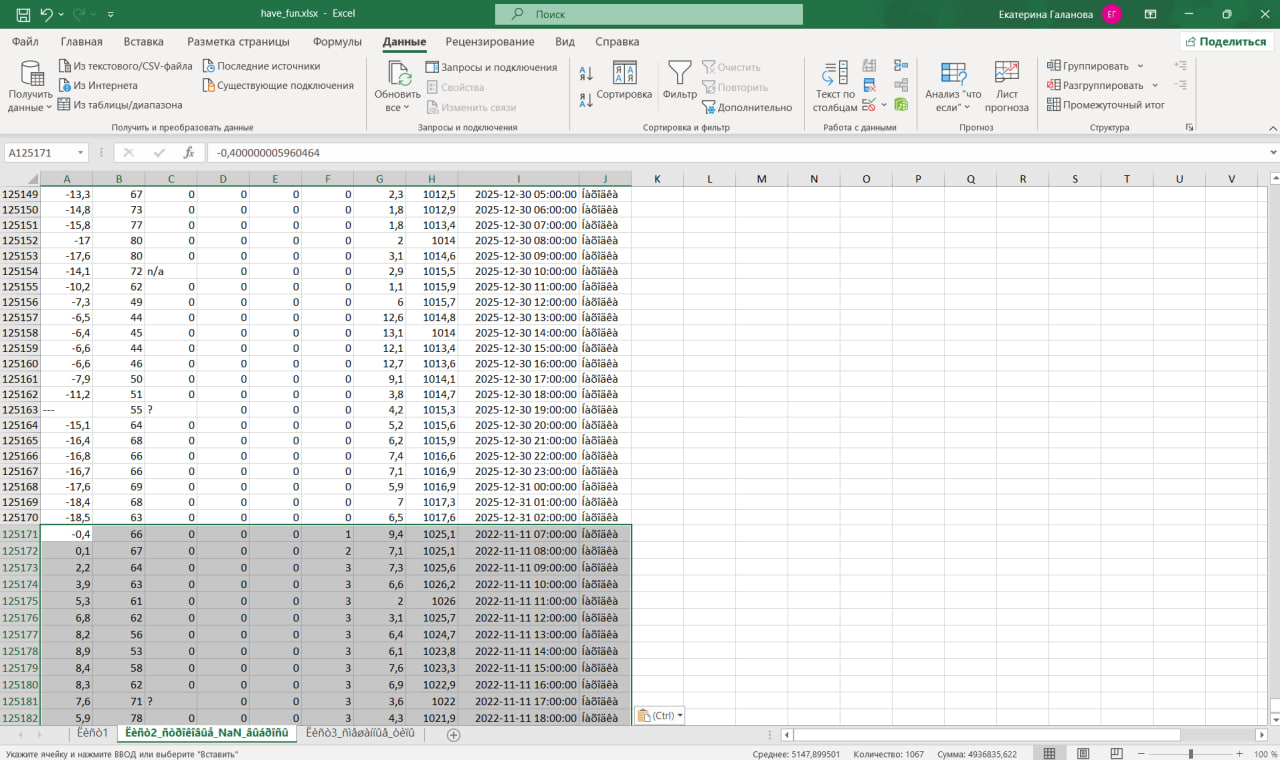

 #### Загружаем данные

In [ ]:
raw = {}
for name in data_sheets:
    raw[name] = pd.read_excel('have_fun_fixed_с_ручным_исправлением.xlsx', sheet_name=name)
    print(f"{name}: {raw[name].shape}")

### Диагностика ошибок

In [ ]:
def diagnose_sheet(df, name):
    print(name)
    print(f"Размер: {df.shape[0]} строк, {df.shape[1]} колонок")

    extra_cols = [c for c in df.columns if str(c).startswith('Unnamed')]
    if extra_cols:
        print(f"\nЛишних колонок: {len(extra_cols)} -> {extra_cols}")

    print("\nТипы колонок")
    print(df.dtypes)

    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if not nulls.empty:
        print("\nПропуски")
        print(nulls)

    print("\nГорода")
    print(df['city'].value_counts())

    dupes = df.duplicated(['ds', 'city']).sum()
    if dupes > 0:
        print(f"\nДубликатов: {dupes}")

    numeric_object_cols = [
        c for c in df.columns
        if df[c].dtype == object and c not in ('city', 'ds')
        and not str(c).startswith('Unnamed')
    ]
    if numeric_object_cols:
        print("\nТекст в числовых колонках")
        for col in numeric_object_cols:
            bad = df[col][pd.to_numeric(df[col], errors='coerce').isna() & df[col].notna()]
            if not bad.empty:
                print(f"  {col}: {bad.unique()}")

    empty_rows = df.isnull().all(axis=1).sum()
    if empty_rows > 0:
        print(f"\nПолностью пустых строк: {empty_rows}")



for name, df in raw.items():
    diagnose_sheet(df, name)

Нашли пропуски, дубликаты, ошибки ручного ввода (неправильные названия городов, строки в столбцах с числами)

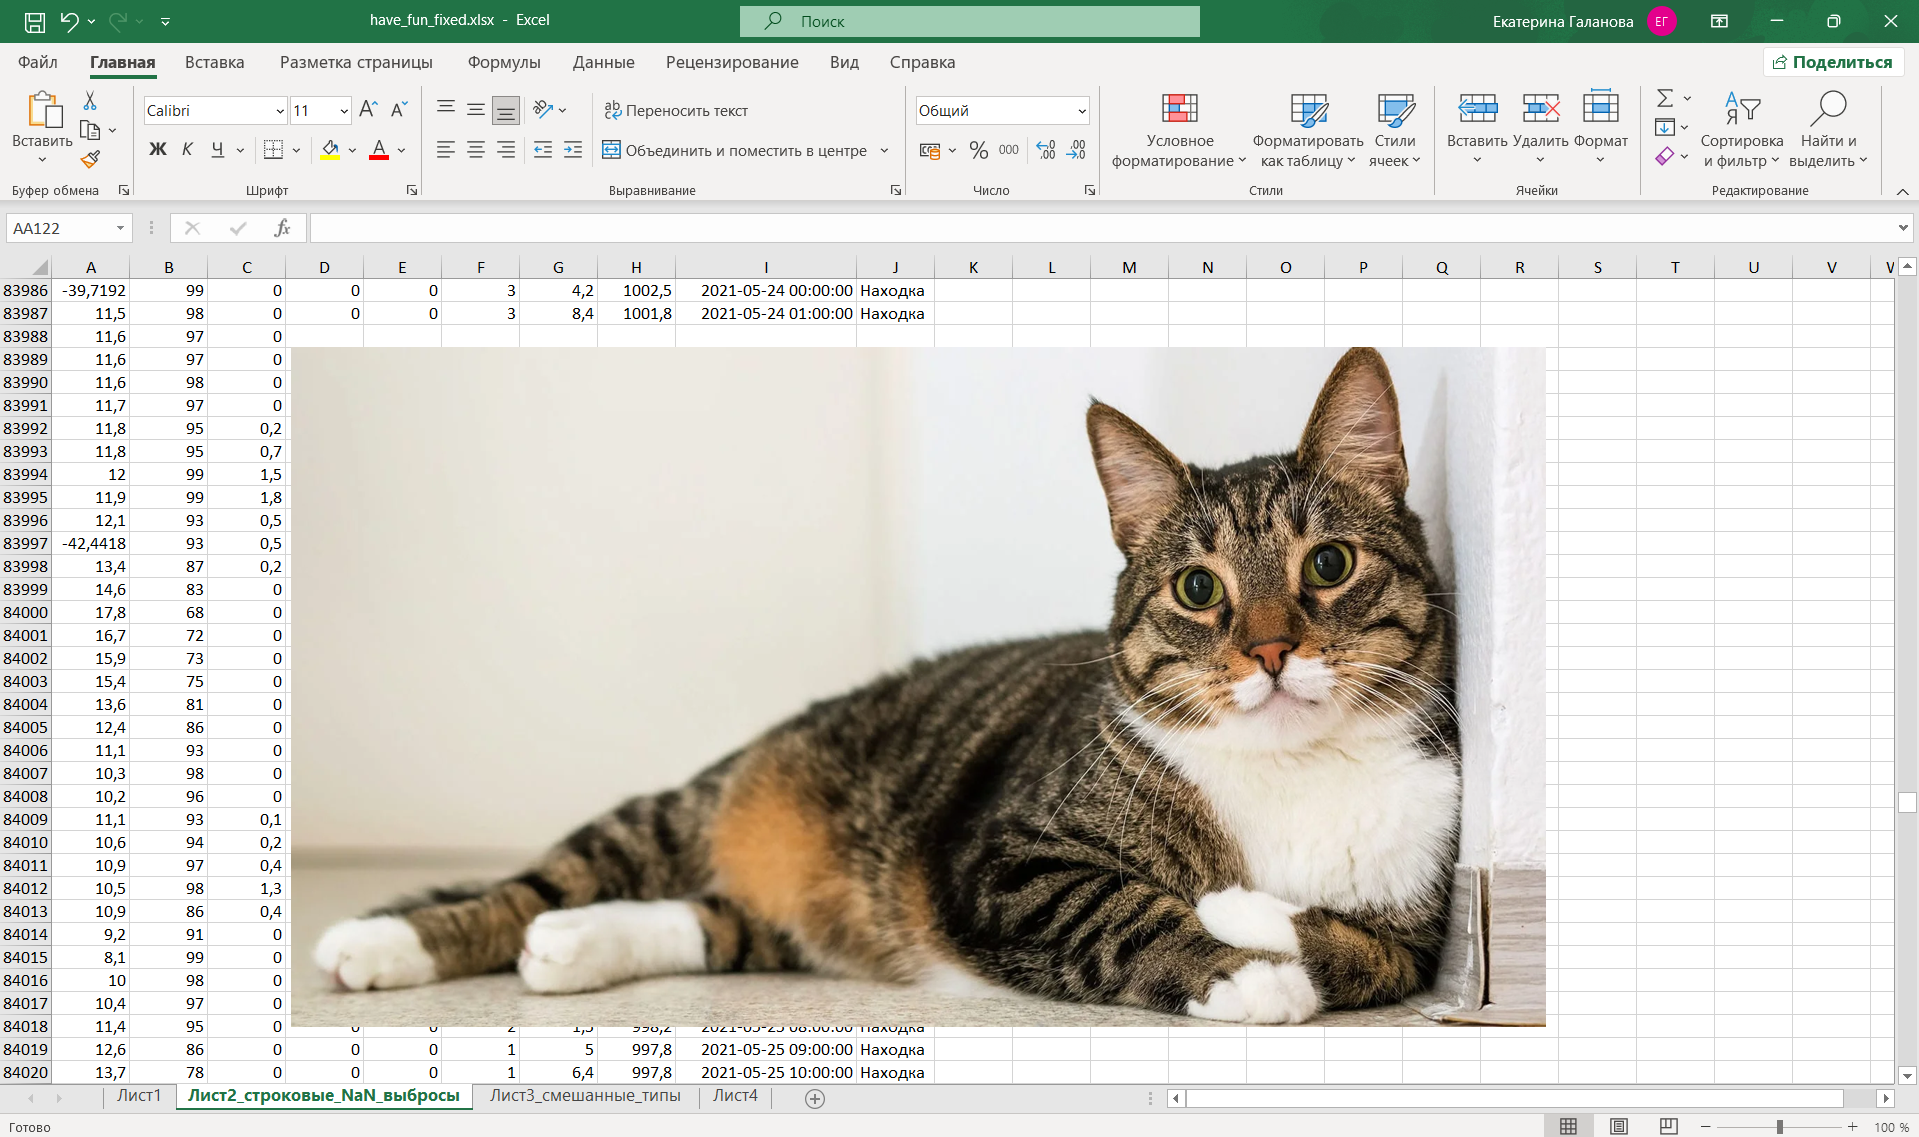

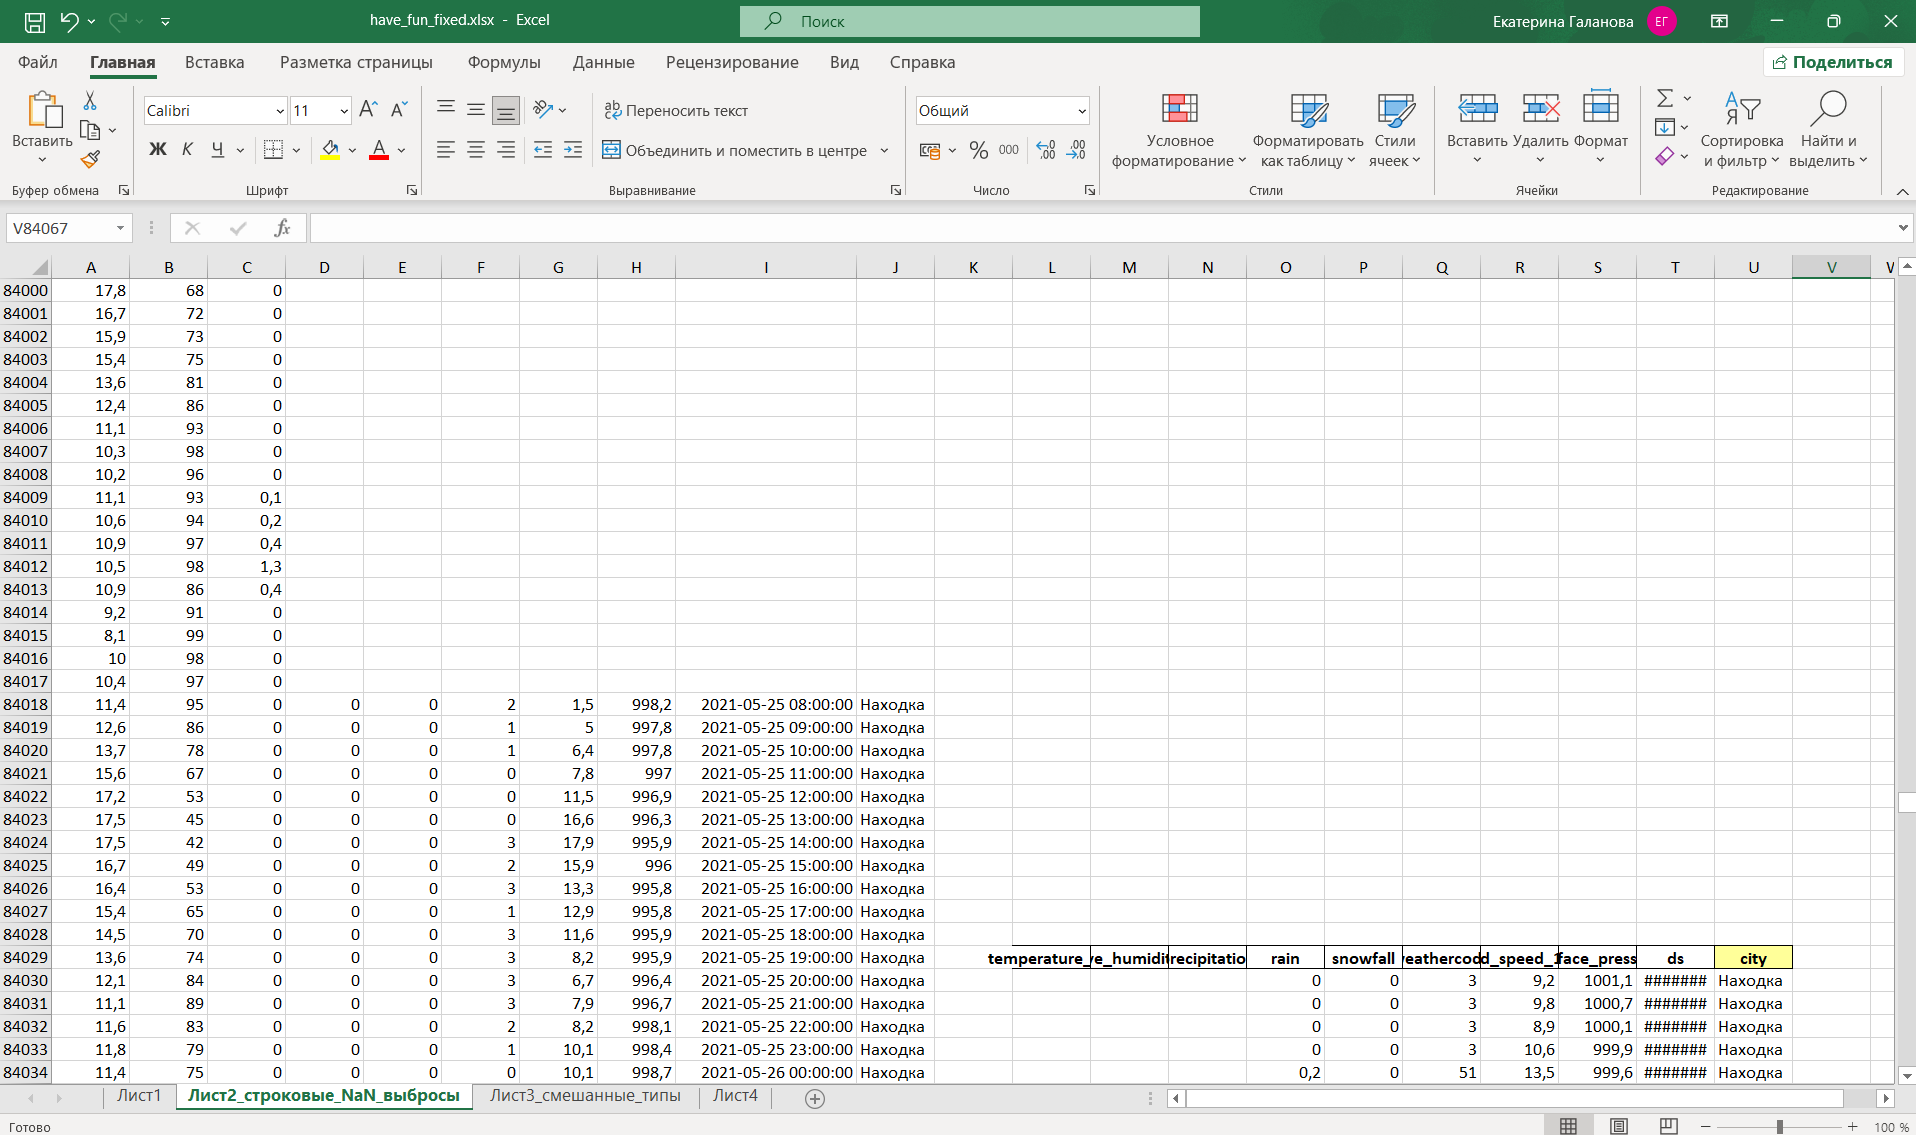

 Тк в листе 2 было 11 лишних колонок, я нашла в таблице лишние и приняла решение переместить лишние колонки на место удаленной фотографии, тк они идеально вписывались. Подразумевается, что они случайно были смещены.

Вот что вывелось:
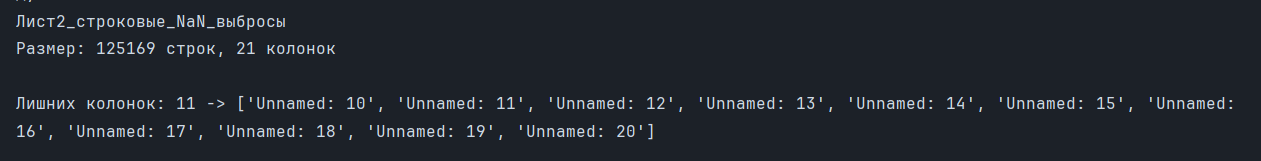

После ручной обработки:
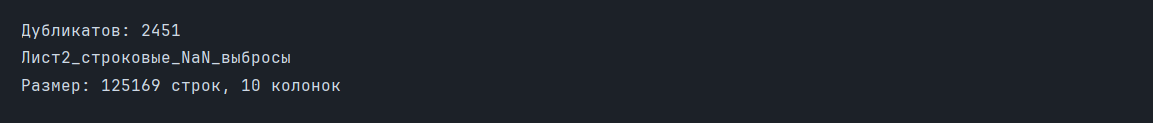
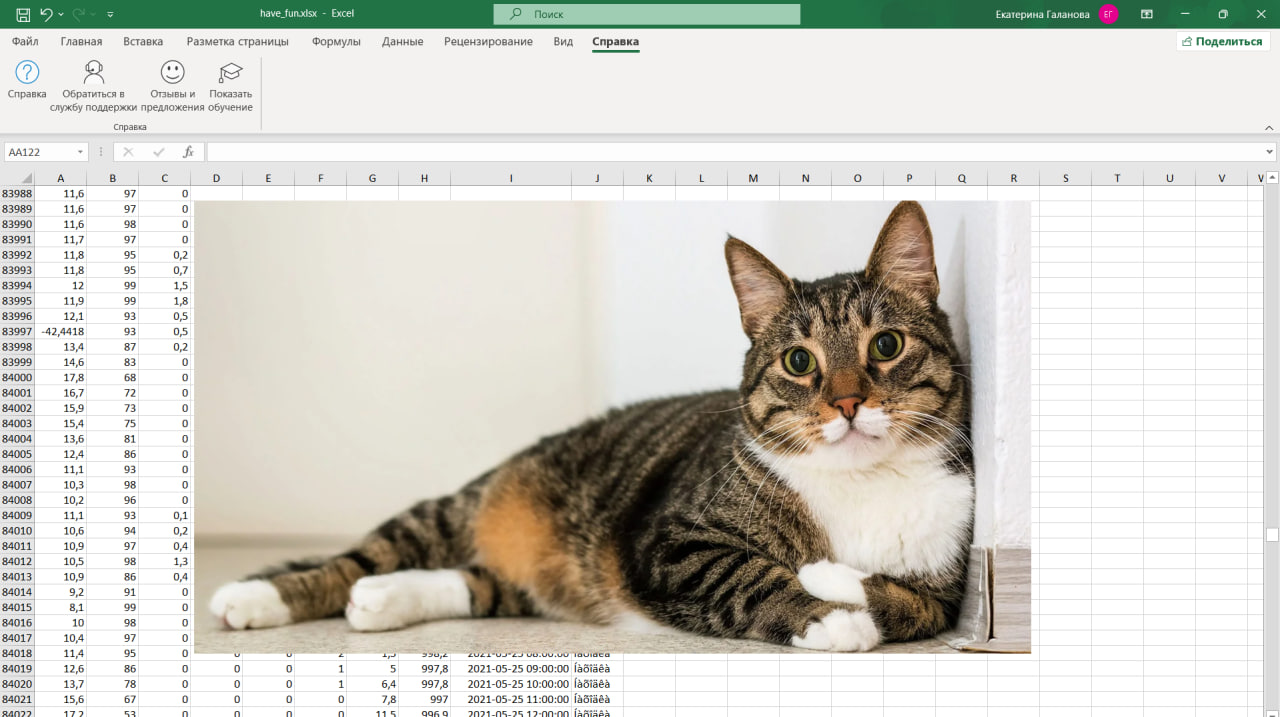
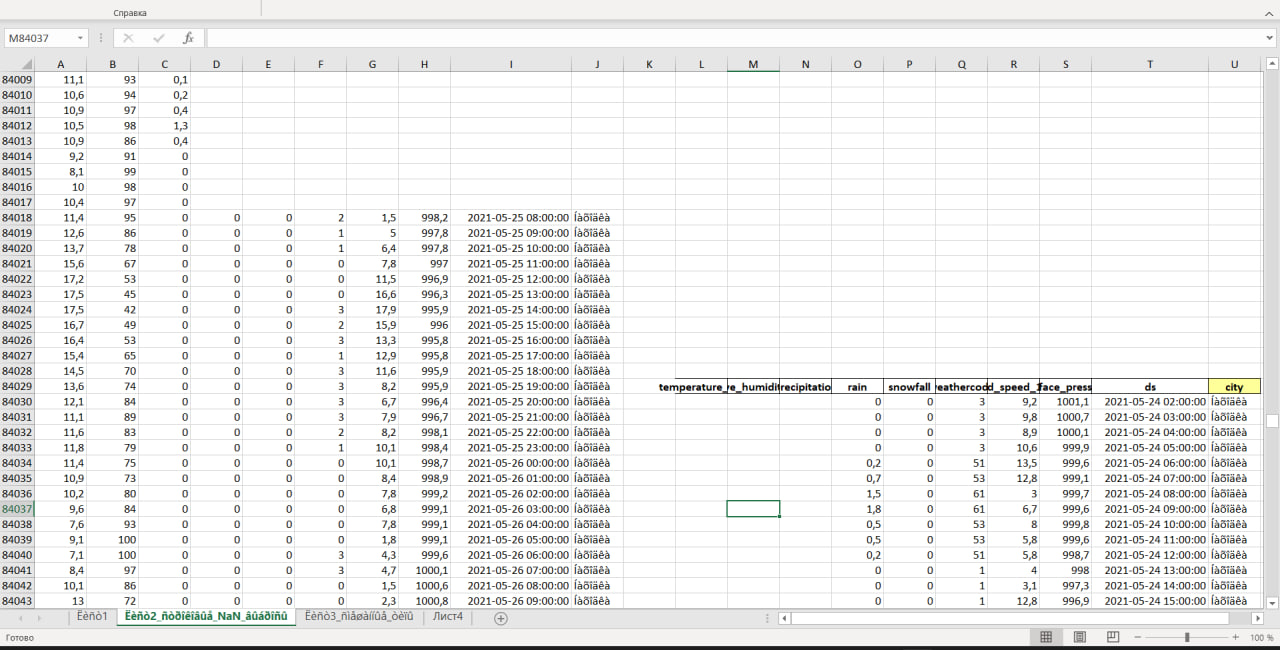
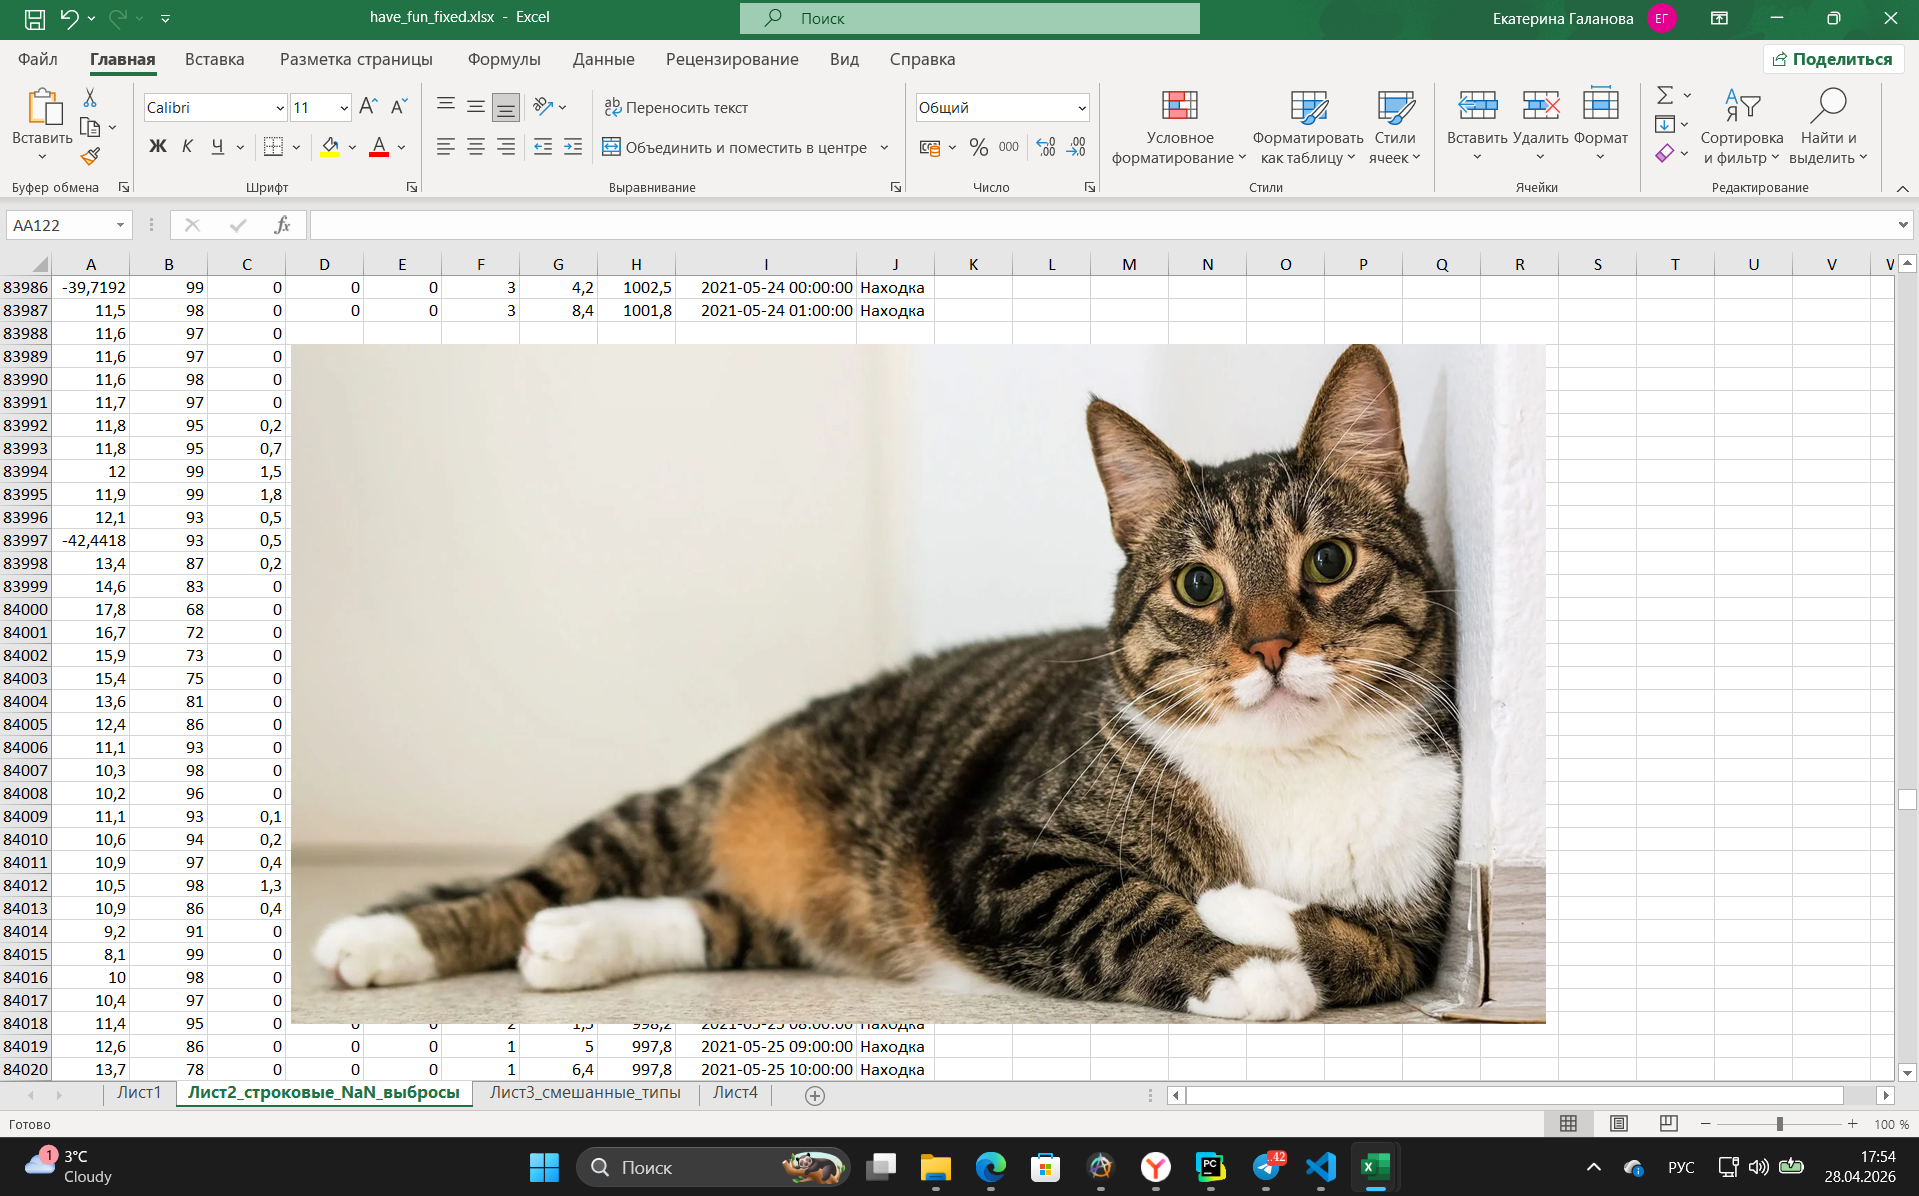
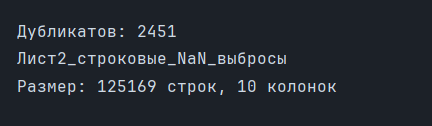

Лист4 я также удалила, так как это дублирование информции из Лист2

### Устранение ошибок в файле

In [ ]:
STRING_NANS = {'нет данных', 'NAN', '---', '?', 'nan',
               'холодно', 'жарко', 'нормально',
               'ветрено', 'шторм', 'гроза', 'тихо', 'туман',
               'солнечно', 'дождь', 'пасмурно', 'снег',
               'морось', 'сухо', 'ливень'}

CITY_MAP = {
    'ГЕЛЕНДЖИК':    'Геленджик',
    'геленджик':    'Геленджик',
    'Геленджикк':   'Геленджик',
    'Геленджи':     'Геленджик',
    'БЛАГОВЕЩЕНСК': 'Благовещенск',
    'благовещенск': 'Благовещенск',
    'Благовещенскк':'Благовещенск',
    'Благовещенс':  'Благовещенск',
    'Мосва':        'Москва',
    'Сычи':         'Сочи',
    'Счи':          'Сочи',
    'Соч':          'Сочи',
}

NUMERIC_COLS = ['temperature_2m', 'relative_humidity_2m', 'precipitation',
                'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure']

cleaned = {}

for sheet_name, df in raw.items():
    print(f"\n{sheet_name} | было {df.shape}")

    unnamed = [c for c in df.columns if str(c).startswith('Unnamed')]
    if unnamed:
        print(f"удаляем Unnamed: {unnamed}")
        df = df.drop(columns=unnamed)

    df = df.dropna(subset=['ds', 'city'])
    df['city'] = df['city'].replace(CITY_MAP)

    for col in NUMERIC_COLS:
        if col not in df.columns:
            continue
        if df[col].dtype == object:
            df[col] = df[col].replace(list(STRING_NANS), np.nan)
            df[col] = pd.to_numeric(df[col], errors='coerce')

    before = len(df)
    df = df.drop_duplicates(subset=['ds', 'city'], keep='first')
    print(f"дубликатов удалено: {before - len(df)}")
    print(f"стало {df.shape}")
    print(f"города: {sorted(df['city'].dropna().unique())}")

    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if not nulls.empty:
        print("пропуски:\n", nulls)

    cleaned[sheet_name] = df

df_all = pd.concat(cleaned.values(), ignore_index=True)
df_all = df_all.sort_values(['city', 'ds']).reset_index(drop=True)
print(f"\nИтого: {df_all.shape}")
print(f"Города: {sorted(df_all['city'].unique())}")

### Обработка выбросов

In [ ]:
sns.set_style("white")
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
df_all = pd.concat(cleaned.values(), ignore_index=True)
df_all['ds'] = pd.to_datetime(df_all['ds'])
df_all = df_all.sort_values(['city', 'ds']).reset_index(drop=True)

sns.histplot(df_all['temperature_2m'], kde=True, ax=axes[0][0])
axes[0][0].set_title("Температура")
sns.histplot(df_all['relative_humidity_2m'], kde=True, ax=axes[0][1])
axes[0][1].set_title("Относительная влажность")
sns.histplot(df_all['precipitation'], kde=True, ax=axes[0][2])
axes[0][2].set_title("Осадки")
sns.histplot(df_all['rain'], kde=True, ax=axes[1][0])
axes[1][0].set_title("Дождь")
sns.histplot(df_all['snowfall'], kde=True, ax=axes[1][1])
axes[1][1].set_title("Снегопад")
sns.histplot(df_all['weathercode'], kde=True, ax=axes[1][2])
axes[1][2].set_title("Код погоды")
sns.histplot(df_all['wind_speed_10m'], kde=True, ax=axes[2][0])
axes[2][0].set_title("Скорость ветра")
sns.histplot(df_all['surface_pressure'], kde=True, ax=axes[2][1])
axes[2][1].set_title("Поверхностное давление")
sns.histplot(df_all['ds'], kde=True, ax=axes[2][2])
axes[2][2].set_title("Дата")

plt.tight_layout()
plt.show()

In [ ]:
# skip_columns = ['rain', 'snowfall', 'precipitation', 'weathercode']
# cols_clean_outliers = [c for c in NUMERIC_COLS if c not in skip_columns]
# это до того как я додумалась искать по городам и месяцам я дропала эти колонки

def fill_missing_with_rolling_mean(series, window):
    rolling_mean = series.rolling(window=window, center=True, min_periods=1).mean()
    return series.fillna(rolling_mean)

def clean_outliers(series, multiplier=1.5):
    emission = 0
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR

    mask = (series < lower_bound) | (series > upper_bound)

    cleaned = series.copy()
    cleaned[mask] = np.nan

    if mask.sum() > 0:
        print(f"Найдено выбросов: {mask.sum()}")

    return cleaned


for sheet_name, df in cleaned.items():
    frames = []
    for city, group in df.groupby('city'):
        group = group.copy()
        print(f"\n{sheet_name} - {city}")

        for col in NUMERIC_COLS:
            for month, m_group in group.groupby(group['ds'].dt.month):
                if col not in group.columns:
                    continue
                group.loc[m_group.index, col] = clean_outliers(m_group[col], multiplier=1.5)
                group[col] = fill_missing_with_rolling_mean(group[col], window=6)
                group[col] = group[col].interpolate(method='linear', limit_direction='both')
        frames.append(group)
    cleaned[sheet_name] = pd.concat(frames).sort_values(['city', 'ds']).reset_index(drop=True)

# Значения не удаляются, а заменяются на nan. Потом nan заменяются на нормальные значения с помощью скольз. среднего и лин. интерполяции

Ищу выбросы на отдельных городах на протяжении месяца. Очевидно, что нормальные значения зависят о месяца и города

In [ ]:
sns.set_style("white")
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
df_all = pd.concat(cleaned.values(), ignore_index=True)
df_all['ds'] = pd.to_datetime(df_all['ds'])
df_all = df_all.sort_values(['city', 'ds']).reset_index(drop=True)

sns.histplot(df_all['temperature_2m'], kde=True, ax=axes[0][0])
axes[0][0].set_title("Температура")
sns.histplot(df_all['relative_humidity_2m'], kde=True, ax=axes[0][1])
axes[0][1].set_title("Относительная влажность")
sns.histplot(df_all['precipitation'], kde=True, ax=axes[0][2])
axes[0][2].set_title("Осадки")
sns.histplot(df_all['rain'], kde=True, ax=axes[1][0])
axes[1][0].set_title("Дождь")
sns.histplot(df_all['snowfall'], kde=True, ax=axes[1][1])
axes[1][1].set_title("Снегопад")
sns.histplot(df_all['weathercode'], kde=True, ax=axes[1][2])
axes[1][2].set_title("Код погоды")
sns.histplot(df_all['wind_speed_10m'], kde=True, ax=axes[2][0])
axes[2][0].set_title("Скорость ветра")
sns.histplot(df_all['surface_pressure'], kde=True, ax=axes[2][1])
axes[2][1].set_title("Поверхностное давление")
sns.histplot(df_all['ds'], kde=True, ax=axes[2][2])
axes[2][2].set_title("Дата")

plt.tight_layout()
plt.show()

In [ ]:
for name, df in cleaned.items():
    df.info() # здесь мы видим что нет больше смешанных типов

### Устранение пропусков

In [ ]:
df_all = pd.concat(cleaned.values(), ignore_index=True)
df_all['ds'] = pd.to_datetime(df_all['ds'])

gaps = []
for city, group in df_all.groupby('city'):
    group = group.set_index('ds').sort_index()
    expected = pd.date_range(group.index.min(), group.index.max(), freq='h')
    missing_hours = expected.difference(group.index)
    gaps.append({'city': city, 'missing_hours': len(missing_hours)})
    if len(missing_hours) > 0:
        print(f"{city}: {len(missing_hours)} пропущенных часов")

In [ ]:
frames = []
for city, group in df_all.groupby('city'):
    group = group.set_index('ds').sort_index()

    full_index = pd.date_range(group.index.min(), group.index.max(), freq='h')
    group = group.reindex(full_index)
    group.index.name = 'ds'
    group['city'] = city

    for col in NUMERIC_COLS:
        if col not in group.columns:
            continue
        group[col] = group[col].interpolate(method='linear', limit_direction='both')

    frames.append(group.reset_index())

df_all = pd.concat(frames, ignore_index=True).sort_values(['city', 'ds']).reset_index(drop=True)
print(f"Итого: {df_all.shape}")
print(df_all['city'].value_counts())

In [ ]:
for city, group in df_all.groupby('city'):
    print(f"{city}: {group['ds'].min()} - {group['ds'].max()}")

Данные Находки заканчиваются раньше. это не критично

### Визуализация

In [ ]:
CITY = 'Москва'

df = df_all.copy()
df1 = df[df['city'] == CITY].copy()
df1['ds'] = pd.to_datetime(df['ds'])
df1 = df1.sort_values('ds').set_index('ds')
df2 = df[df['city'] == 'Благовещенск'].copy()
series2 = df2['temperature_2m']
df3 = df[df['city'] == 'Сочи'].copy()
series3 = df3['temperature_2m']
df4 = df[df['city'] == 'Санкт-Петербург'].copy()
series4 = df4['temperature_2m']
df5 = df[df['city'] == 'Находка'].copy()
series5 = df5['temperature_2m']
df6 = df[df['city'] == 'Геленджик'].copy()
series6 = df6['temperature_2m']
series = df1['temperature_2m']

In [ ]:
def temperature(series, city):
    plt.figure(figsize=(15, 6))

    plt.plot(series, label='Температура', color='steelblue')
    plt.plot(series.rolling(window=24*30).mean(),
             label='Скользящее среднее за месяц', color='orange')

    plt.legend(title='', loc='upper left', fontsize=14)
    plt.xlabel('Дата', fontsize=14)
    plt.ylabel('Температура (градусов Цельсия)', fontsize=14)
    plt.title(f'Температура в {city} по часам', fontsize=16)
    plt.show()
temperature(series, 'Москве')
temperature(series2, 'Благовещенске')
temperature(series3, 'Сочи')
temperature(series4, 'Санкт-Петербурге')
temperature(series5, 'Находке')
temperature(series6, 'Геленджике')


**Визуализация временного ряда**

На графике видна чёткая годовая сезонность, в каждом городе различная нормальная температура. Скользящее среднее за 30 дней сглаживает суточный шум и наглядно показывает годовой тренд - пики летом и провалы зимой повторяются стабильно на всём периоде.

In [ ]:
rcParams['figure.figsize'] = 11, 9

decompose = seasonal_decompose(series.dropna(), period=24*365)
decompose.plot()
plt.show()

**Декомпозиция** Москва

Ряд разложен на три компоненты:

- **Тренд** - долгосрочное среднее температуры колеблется в диапазоне 5.8–8.5 градусов Цельсия.
  Заметно небольшое снижение в 2021–2024 и восстановление к 2025–2026.
- **Сезонность** - годовой цикл с амплитудой +-20 градусов Цельсия: летние пики и зимние провалы
  повторяются каждый год с постоянной формой.
- **Остатки** - шум в диапазоне +-10C без выраженного тренда, отражает
  краткосрочные погодные аномалии.
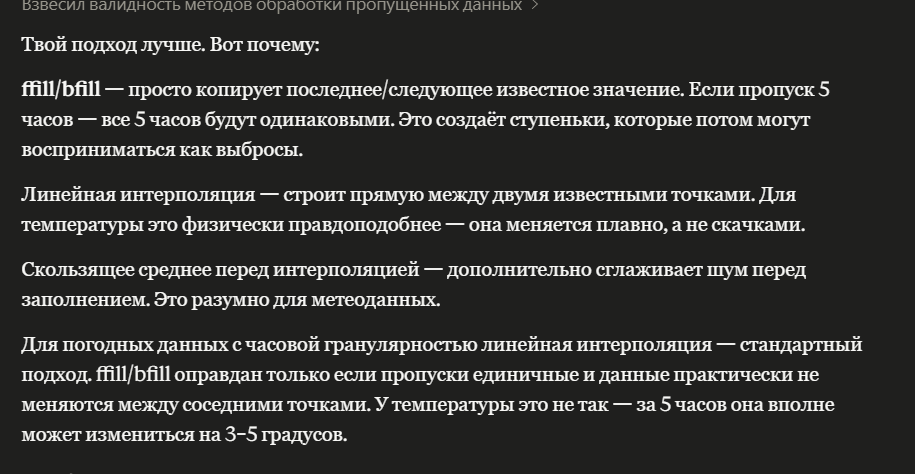

In [ ]:
def test_diki_fuller(series):
    result = adfuller(series.dropna())
    print(f'p-value до дифференцирования: {result[1]:.4f}')

    diff_series = series.diff().dropna()
    result_diff = adfuller(diff_series)
    print(f'p-value после дифференцирования: {result_diff[1]:.4f}')
print('Москва стационарность')
test_diki_fuller(series)
print('Благовещенск стационарность')
test_diki_fuller(series2)
print('Сочи стационарность')
test_diki_fuller(series3)
print('Санкт-Петербург стационарность')
test_diki_fuller(series4)
print('Находка стационарность')
test_diki_fuller(series5)
print('Геленджик стационарность')
test_diki_fuller(series6)

**Проверка стационарности (тест Дики-Фуллера)**

p-value = 0.0000 < 0.05 - ряд стационарен как до, так и после дифференцирования.
Это означает, что среднее и дисперсия ряда стабильны во времени,
дополнительная трансформация данных перед обучением модели не требуется.

In [ ]:
df_plot = df1.copy()
df_plot['month'] = df_plot.index.month

fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(data=df_plot, x='month', y='temperature_2m', ax=ax)
ax.set_xlabel('Месяц')
ax.set_ylabel('Температура')
ax.set_title(f'Распределение температуры по месяцам ({CITY})')
plt.show()

**Распределение температуры по месяцам**

Box plot показывает медиану, межквартильный размах и выбросы для каждого месяца.
Чётко видна годовая сезонность: декабрь-февраль - самые холодные месяцы, июнь-август - самые тёплые.
Небольшие выбросы в переходные месяцы (март, октябрь) отражает нестабильность погоды.

Берем FFT а не вайвлет анализ, нет надобности в вейвлет анализе. Так как переодичность температуры стабильна во времени, занчит FFT подходит.

In [ ]:
series = df1['temperature_2m'].values
n = len(series)
fs = 1

fft_values = fft(series)
frequencies = fftfreq(n, d=1/fs)

half = n // 2
power = np.abs(fft_values[:half])
freqs = frequencies[:half]

nonzero = freqs > 0
periods = 1 / freqs[nonzero]
power_nz = power[nonzero]

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

axes[0].plot(freqs[nonzero], power_nz, color='steelblue', linewidth=0.8)
axes[0].set_xlabel('Частота (циклов/час)')
axes[0].set_ylabel('Амплитуда')
axes[0].set_title(f'FFT-спектр температуры ({CITY})')

axes[0].axvline(1/24, color='red', linestyle='--', label='Суточный (1/24)')
axes[0].axvline(1/8760, color='orange', linestyle='--', label='Годовой (1/8760)')
axes[0].legend()

top_idx = np.argsort(power_nz)[-10:][::-1]
top_periods = periods[top_idx]
top_power = power_nz[top_idx]

axes[1].bar(range(10), top_power, color='steelblue')
axes[1].set_xticks(range(10))
axes[1].set_xticklabels([f'{p:.0f}ч' for p in top_periods], rotation=45)
axes[1].set_ylabel('Амплитуда')
axes[1].set_title('Топ-10 доминирующих периодов')

plt.tight_layout()
plt.show()

print("Топ-5 доминирующих периодов:")
for p, amp in zip(top_periods[:5], top_power[:5]):
    print(f"  Период: {p:.1f} ч ({p/24:.1f} дней), амплитуда: {amp:.1f}")

FFT анализ подтвердил два доминирующих периода: годовой 8767 ч, 365.3 дня с амплитудой 400724 и суточный 24 ч с амплитудой 77490. Годовой цикл значительно превосходит суточный, что объясняется большим диапазоном сезонных колебаний температуры в Москве. Периоды 24.1 и 23.9 ч являются соседними бинами FFT вокруг суточного пика. Выявленные периоды обосновывают включение в признаковое пространство переменных hour и day_of_year.

In [ ]:
# Берём дневные средние, иначе будет много лагов и ничего не видно
daily = df1['temperature_2m'].resample('D').mean()

fig, axes = plt.subplots(2, 1, figsize=(15, 8))

plot_acf(daily, lags=60, ax=axes[0])
axes[0].set_title('ACF температуры (дневное среднее)')
axes[0].set_xlabel('Лаг (дни)')

plot_pacf(daily, lags=60, ax=axes[1])
axes[1].set_title('PACF температуры (дневное среднее)')
axes[1].set_xlabel('Лаг (дни)')

plt.tight_layout()
plt.show()

ACF демонстрирует медленное убывание с сохранением значимой корреляции вплоть до лага 60 дней, что характерно для рядов с выраженной сезонностью. PACF резко обрывается после лага 3: лаги 1 (0.95), 2 (−0.20) и 3 (0.25) статистически значимы, остальные находятся в пределах доверительного интервала. Это означает, что прямая зависимость ограничена 3 днями, тогда как более длинная "память" ряда обусловлена транзитивными связями через сезонность. Исходя из этого, в feature engineering включаются лаги 1-7 дней, а также скользящие статистики с окнами 7 и 14 дней.

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))
for city, group in df_all.groupby('city'):
    daily = group.set_index('ds')['temperature_2m'].resample('D').mean()
    ax.plot(daily, label=city, alpha=0.7)
ax.legend()
ax.set_title('Температура по городам (дневное среднее)')

Демонстрирую, что разделение по городам критически важно, ибо погода различается в зависимости от географического расположения

### Feature engineering

In [ ]:
sns.set_style("white")
df_cor = df_all.copy()
numeric_df = df_cor.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm')
plt.title("Корреляция числовых признаков")
plt.show()

#### Меняю гранулярность!
в задаче у нас **предсказать температуру на следующие 7 дней**. предсказывать на 7*24 часа - это очень много. + объем данных значительно уменьшится и будет более емким, если часы сменить на дни. Логично взять среднее значение за день, но не для всех столбцов

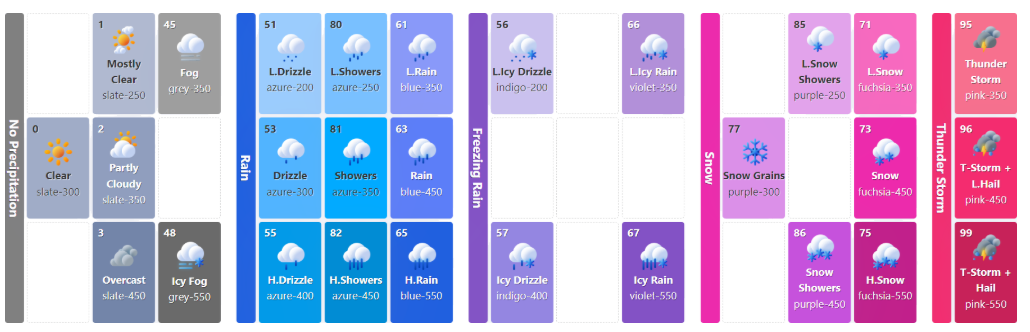

Интересный факт! weathercode значит что-то конкретное. Не то, насколько хорошая или плохая погода, а определенные погодные условия. поэтому искать среднее - идея не очень. часть дня ясно - часть гроза, найдем среднее - получится снег, а на дворе лето! сомнительно но окей. Поэтому я приняла решение брать максимальное значение для дня

В осадках и так сплошные нули, я возьму сумму осадков (и снега и дождя) за день

In [ ]:
df_daily = df_all.groupby('city').resample('D', on='ds').agg({
    'temperature_2m': 'mean',
    'relative_humidity_2m': 'mean',
    'wind_speed_10m': 'mean',
    'surface_pressure': 'mean',
    'precipitation': 'sum',
    'rain': 'sum',
    'snowfall': 'sum',
    'weathercode': 'max'
}).reset_index()

print(df_daily.head())

In [ ]:
sns.set_style("white")
df_cor = df_daily.copy()
numeric_df = df_cor.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm')
plt.title("Корреляция числовых признаков")
plt.show()

Корреляция улучшилась (чуть-чуть) !!
Но rain и snowfall плохо коррелируют с precipitation, это очень странно, так как по идее precipitation = snowfall + rain.

In [ ]:
df_daily['precipitation'] = np.where(
    df_daily['precipitation'] < (df_daily['snowfall'] + df_daily['rain']),
    df_daily['snowfall'] + df_daily['rain'],
    df_daily['precipitation']
)

Я заменила те столбцы с осадками на снег+дождь, если снег + дождь < осадков. Корреляция не очень от этого меняется. Я вообще удалю столбцы со снегом и дождем, так как корреляция у них слабая, хотя вроде бы должна быть корреляция с осадками. осадки оставляем

In [ ]:
df_daily = df_daily.drop(['rain','snowfall'], axis=1)

#### Создание таргета

Таргет - это то, что модель должна предсказать. Наша задача - прогноз температуры
на 7 дней вперёд, поэтому для каждой строки с датой T таргет = температура в день T+7.

shift(-7) внутри groupby по городу сдвигает значения на 7 строк вверх отдельно
для каждого города, иначе последние 7 дней одного города брали бы данные
из следующего города по алфавиту.

Последние 7 строк каждого города получают NaN (будущего нет), их удаляем через dropna.

In [ ]:
df_daily['target'] = df_daily.groupby('city')['temperature_2m'].shift(-7)
df_daily = df_daily.dropna(subset=['target'])

#### Признаки и их корреляция с таргетом

Корреляция с таргетом показывает насколько каждый признак линейно связан
с температурой через 7 дней. Это помогает отобрать полезные признаки
и отсеять бесполезные перед обучением.

In [ ]:
def add_features(df):
    parts = []
    for city, g in df.groupby('city'):
        g = g.copy().sort_values('ds')
         # календарные признаки
        g['month']       = g['ds'].dt.month
        g['day_of_year'] = g['ds'].dt.dayofyear
        # лаги температуры - значения за 1,2,3,7,14,30 дней до текущего дня
        # внутри groupby лаги не перетекают из одного города в другой
        for lag in [1, 2, 3, 7, 14, 30]:
            g[f'lag_{lag}'] = g['temperature_2m'].shift(lag)
        # скользящие статистики по окнам 7, 14, 30 дней
        # shift(1) перед rolling, чтобы не использовать текущий день
        # то есть roll_mean_7 = среднее за последние 7 дней до текущего
        for w in [7, 14, 30]:
            g[f'roll_mean_{w}'] = g['temperature_2m'].shift(1).rolling(w).mean()
            g[f'roll_std_{w}']  = g['temperature_2m'].shift(1).rolling(w).std()
            g[f'roll_min_{w}']  = g['temperature_2m'].shift(1).rolling(w).min()
            g[f'roll_max_{w}']  = g['temperature_2m'].shift(1).rolling(w).max()
        # синус и косинус дня года, циклическое кодирование сезонности
        g['day_sin']   = np.sin(2 * np.pi * g['day_of_year'] / 365)
        g['day_cos']   = np.cos(2 * np.pi * g['day_of_year'] / 365)
        g['month_sin'] = np.sin(2 * np.pi * g['month'] / 12)
        g['month_cos'] = np.cos(2 * np.pi * g['month'] / 12)
        # разность температур между текущим днём и неделю назад
        # показывает тренд: растёт температура или падает
        g['diff_7'] = g['temperature_2m'].diff(7)
        parts.append(g)

    return pd.concat(parts).dropna()

In [ ]:
df_daily_feat = add_features(df_daily)
print(df_daily_feat.shape)
print(df_daily_feat.columns.tolist())

In [ ]:
numeric_df = df_daily_feat.select_dtypes(include=['number'])
target_corr = numeric_df.corr()['target']

print("Корреляция признаков с таргетом:")
print(target_corr)

In [ ]:
drop_cols = ['day_of_week', 'diff_1', 'diff_7', 'precipitation', 'surface_pressure']
existing_cols = [col for col in drop_cols if col in df_daily_feat.columns]

df_daily_feat = df_daily_feat.drop(columns=existing_cols)

In [ ]:
df_daily_feat.info()

In [ ]:
df_city = df_daily_feat.copy().sort_values('ds').reset_index(drop=True) # здесь сортирую по дате именно так как если еще сортировать по городу, то у нас модель для трена возьмет там первые города по алфавиту, а надо чтобы первые даты брала

# city_enc - числовой код города (0=Благовещенск, 1=Геленджик и тд)
# label encoding вместо one-hot: деревьям не нужен one-hot, они сами находят оптимальные группировки по числу
df_city['city_enc'] = df_city['city'].astype('category').cat.codes
n = len(df_city)

feature_cols = [c for c in df_city.columns
                if c not in ['ds', 'city', 'temperature_2m', 'target']]

X_all = df_city[feature_cols]
y_all = df_city['target']

train_end = int(n * 0.7)
val_end   = int(n * 0.85)

X_tr = X_all.iloc[:train_end]
y_tr = y_all.iloc[:train_end]
X_vl = X_all.iloc[train_end:val_end]
y_vl = y_all.iloc[train_end:val_end]
X_te = X_all.iloc[val_end:]
y_te = y_all.iloc[val_end:]

print(f"Train: {len(X_tr)}, Val: {len(X_vl)}, Test: {len(X_te)}")

# Проверка утечки
train_dates = df_city.iloc[:train_end]['ds']
val_dates   = df_city.iloc[train_end:val_end]['ds']
test_dates  = df_city.iloc[val_end:]['ds']

assert len(set(train_dates) & set(val_dates)) == 0, "утечка train/val!"
assert len(set(val_dates)   & set(test_dates)) == 0, "утечка val/test!"
assert train_dates.max() < val_dates.min(), "train позже val!"
assert val_dates.max()   < test_dates.min(), "val позже test!"

print(f"Train:  {train_dates.min().date()} -> {train_dates.max().date()}")
print(f"Val:    {val_dates.min().date()} -> {val_dates.max().date()}")
print(f"Test:   {test_dates.min().date()} -> {test_dates.max().date()}")
print("Утечки нет")

### Optuna

Optuna автоматически подбирает гиперпараметры для каждой модели.
Вместо ручного перебора она запускает N попыток, каждый раз обучая модель
на train и оценивая MAE на val. Алгоритм TPE сужает поиск на основе
предыдущих результатов - хорошие области исследуются подробнее.

Обучение происходит только на X_tr, оценка только на X_vl.
Test не участвует нигде - это гарантирует честную финальную оценку.

In [ ]:
def objective_lgbm(trial):
    # параметры применяемые на практике, параметры для optuna
    params = {
        'n_estimators':   trial.suggest_int('n_estimators', 100, 800),
        'learning_rate':  trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth':      trial.suggest_int('max_depth', 3, 10),
        'num_leaves':     trial.suggest_int('num_leaves', 16, 128),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample':      trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42, 'n_jobs': -1, 'verbose': -1
    }
    # обучение
    model = LGBMRegressor(**params)
    model.fit(X_tr, y_tr)
    return mean_absolute_error(y_vl, model.predict(X_vl))
# ищем параметры при которых MAE минимален, 50 попыток
study_lgbm = optuna.create_study(direction='minimize')
study_lgbm.optimize(objective_lgbm, n_trials=50, show_progress_bar=True)

print(f"\nOptuna LightGBM лучшее MAE на val: {study_lgbm.best_value:.3f}")
print(f"Лучшие параметры: {study_lgbm.best_params}")
# лучшие параметры подбираем
best_lgbm = LGBMRegressor(**study_lgbm.best_params, random_state=42, n_jobs=-1, verbose=-1)
best_lgbm.fit(X_tr, y_tr)

# для Random Forest, так как разные модели с разными настройками
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth':    trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5]),
        'random_state': 42, 'n_jobs': -1
    }
    model = RandomForestRegressor(**params)
    model.fit(X_tr, y_tr)
    return mean_absolute_error(y_vl, model.predict(X_vl))

study_rf = optuna.create_study(direction='minimize')
study_rf.optimize(objective_rf, n_trials=30, show_progress_bar=True)

best_rf = RandomForestRegressor(**study_rf.best_params, random_state=42, n_jobs=-1)
best_rf.fit(X_tr, y_tr)
print(f"\nOptuna RF лучшее MAE на val: {study_rf.best_value:.3f}")

# для Decision Tree
def objective_dt(trial):
    params = {
        'max_depth':        trial.suggest_int('max_depth', 2, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 30),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'random_state': 42
    }
    model = DecisionTreeRegressor(**params)
    model.fit(X_tr, y_tr)
    return mean_absolute_error(y_vl, model.predict(X_vl))

study_dt = optuna.create_study(direction='minimize')
study_dt.optimize(objective_dt, n_trials=30, show_progress_bar=True)

best_dt = DecisionTreeRegressor(**study_dt.best_params, random_state=42)
best_dt.fit(X_tr, y_tr)
print(f"Optuna DT лучшее MAE на val: {study_dt.best_value:.3f}")


Сравниваем best_value трёх моделей на val:
- Optuna LightGBM лучшее MAE на val: 2.714
- Optuna RF лучшее MAE на val: 2.750
- Optuna DT лучшее MAE на val: 3.021

LightGBM показал наименьшую ошибку - эти параметры будем использовать
для финального обучения. Разрыв между LightGBM и DT (~0.3) объясняется
тем что бустинг последовательно исправляет ошибки предыдущих деревьев,
тогда как одно дерево не может уловить сложные зависимости.

Найденные параметры фиксируются и дальше используются в:
1. Expanding Window CV
2. Финальной модели
3. Стратегиях Direct и Recursive

 у sklearn MAPE нет защиты от деления на 0. Не все метрики есть в sklearn, пишем сами кроме MAE

In [ ]:
def wape(y_true, y_pred):
    denom = np.sum(np.abs(y_true))
    if denom < 1e-8:
        return np.nan
    return np.sum(np.abs(y_true - y_pred)) / denom * 100

def mape(y_true, y_pred):
    mask = np.abs(y_true) > 0.1  # избегаем деления на 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def directional_accuracy(y_true, y_pred):
    true_dir = np.sign(np.diff(y_true))
    pred_dir = np.sign(np.diff(y_pred))
    return np.mean(true_dir == pred_dir) * 100

def directional_r2(y_true, y_pred):
    true_dir = np.sign(np.diff(y_true))
    pred_dir = np.sign(np.diff(y_pred))
    if np.std(true_dir) == 0 or np.std(pred_dir) == 0:
        return 0.0
    corr = np.corrcoef(true_dir, pred_dir)[0, 1]
    return corr ** 2

def evaluate(name, y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    print(f"{name}")
    print(f"MAE:                  {mean_absolute_error(y_true, y_pred):.3f}")
    print(f"R2:                   {r2_score(y_true, y_pred):.3f}")
    print(f"WAPE:                 {wape(y_true, y_pred):.2f}%")
    print(f"MAPE:                 {mape(y_true, y_pred):.2f}%")
    print(f"Directional Accuracy: {directional_accuracy(y_true, y_pred):.1f}%")
    print(f"Directional R2:       {directional_r2(y_true, y_pred):.3f}")

### Расширяющееся окно

Я решила, что расширяющееся лучше для погоды, чем скользящее, так как чем больше информации за предыдущие года о температуре, тем проще сделать прогноз, явного тренда там не наблюдается и недавние значеня не должны сильно отличаться от предыдущих


Expanding Window CV проверяет что найденные Optuna параметры не переобучены на конкретном val-сплите, а стабильно работают на разных временных отрезках.

Train начинается с минимума в 365 дней (чтобы модель видела хотя бы один годовой цикл) и расширяется на 30 дней с каждым фолдом. Test каждого фолда - следующие 7 дней после train, модель их не видела.

In [ ]:
HORIZON   = 7
MIN_TRAIN = 365
STEP      = 30

df_cv        = df_city.copy()
full_series  = df_cv[df_cv['city'] == 'Москва']['temperature_2m'].values
feature_cols = [c for c in df_cv.columns if c not in ['ds', 'city', 'temperature_2m', 'target']]
dates        = sorted(df_cv['ds'].unique())
n_samples    = len(dates)

folds = []
current_train_end = MIN_TRAIN
while current_train_end + HORIZON <= n_samples:
    folds.append({
        'train_end':  current_train_end,
        'test_start': current_train_end,
        'test_end':   current_train_end + HORIZON,
    })
    current_train_end += STEP

print(f"Сгенерировано {len(folds)} фолдов (Expanding Window)\n")

fold_results = []
for fold in folds:
    train_dates = dates[:fold['train_end']]
    test_dates  = dates[fold['test_start']:fold['test_end']]

    train_df = df_cv[df_cv['ds'].isin(train_dates)]
    test_df  = df_cv[df_cv['ds'].isin(test_dates)]

    X_cv_tr = train_df[feature_cols]
    y_cv_tr = train_df['target']
    X_cv_te = test_df[feature_cols]
    y_cv_te = test_df['target']

    if y_cv_te.isna().any() or y_cv_tr.isna().any():
        continue

    model = LGBMRegressor(**study_lgbm.best_params, random_state=42, n_jobs=-1, verbose=-1)
    model.fit(X_cv_tr, y_cv_tr)
    preds = model.predict(X_cv_te)

    fold_results.append({
        'train_size': fold['train_end'],
        'mae':        mean_absolute_error(y_cv_te, preds),
        'wape':       wape(y_cv_te.values, preds),
    })

results_df = pd.DataFrame(fold_results)
print(results_df.to_string(index=False))
print(f"\nСреднее MAE:  {results_df['mae'].mean():.3f} +- {results_df['mae'].std():.3f}")
print(f"Среднее WAPE: {results_df['wape'].mean():.2f}%")

Модель прошла проверку на 72 фолдах, что подтверждает её устойчивость.
Средняя ошибка 2.8 градусов Цельсия является приемлемой для прогноза на неделю вперед.
Четкой корреляции между увеличением train_size и падением MAE не наблюдается. Это говорит о том, что для погоды свежие данные (последний год) важнее, чем глубокая история, так как климат меняется.

### Финальная модель и оценка

Финальная модель обучается на train + val с лучшими параметрами из Optuna.
Val добавляется в train только здесь - до этого он использовался исключительно
для подбора параметров. Test используется единственный раз для честной оценки.

Сравниваем три модели по всем метрикам:
- MAE - средняя абсолютная ошибка в градусах Цельсия
- WAPE - взвешенная ошибка, устойчива к температурам около нуля
- MAPE - процентная ошибка (нестабильна при T ~0)
- Directional Accuracy - как часто модель угадывает направление изменения
- Directional R2 - насколько предсказанные направления коррелируют с реальными

In [ ]:
X_tv = pd.concat([X_tr, X_vl])
y_tv = pd.concat([y_tr, y_vl])

final_dt   = DecisionTreeRegressor(**study_dt.best_params, random_state=42)
final_rf   = RandomForestRegressor(**study_rf.best_params, random_state=42, n_jobs=-1)
final_lgbm = LGBMRegressor(**study_lgbm.best_params, random_state=42, n_jobs=-1, verbose=-1)

final_dt.fit(X_tv, y_tv)
final_rf.fit(X_tv, y_tv)
final_lgbm.fit(X_tv, y_tv)

print("Финальная оценка на Test")
evaluate("Decision Tree",       y_te, final_dt.predict(X_te))
evaluate("Random Forest",       y_te, final_rf.predict(X_te))
evaluate("LightGBM (Boosting)", y_te, final_lgbm.predict(X_te))

Лучшая модель - LightGBM, она наиболее точно предсказывает как сами значения (MAE), так и направление изменений (80.8%).

Переход от одного дерева к ансамблям (RF и LGBM) позволил снизить ошибку MAE на 9% и существенно поднять точность угадывания трендов.

Полученное значение R2 (~0.9) подтверждает, что выбранные признаки и параметры моделей позволяют построить качественную систему прогнозирования.

На метрику MAPE мы не смотрим, так как около нулевых значений очень сильно штрафует

In [ ]:
plot_df = df_city.iloc[val_end:].copy()
plot_df['predicted'] = final_lgbm.predict(X_te)
plot_df['actual']    = y_te.values
plot_df['target_date'] = pd.to_datetime(plot_df['ds']) + pd.Timedelta(days=7)

for target_city in plot_df['city'].unique():
    city_df = plot_df[plot_df['city'] == target_city].sort_values('target_date')

    plt.figure(figsize=(15, 6))
    plt.plot(city_df['target_date'], city_df['actual'],
             label='Фактическая температура', color='blue', linewidth=2)
    plt.plot(city_df['target_date'], city_df['predicted'],
             label='Прогноз LightGBM (горизонт 7 дней)', color='red',
             linestyle='--', linewidth=2)

    plt.title(f'Прогноз vs факт - {target_city}', fontsize=16)
    plt.xlabel('Дата прогноза', fontsize=12)
    plt.ylabel('Температура (градусов Цельсия)', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Стратегии прогнозирования

Задача - предсказать температуру на 7 дней вперёд. Есть два подхода.

**Direct (прямая стратегия)** - обучаем 7 отдельных моделей, каждая сразу
предсказывает свой горизонт. Модель для h=1 обучена на таргете "температура
через 1 день", модель для h=7 - на таргете "температура через 7 дней".
Каждая модель независима и оптимальна для своего горизонта.

**Recursive (рекурсивная стратегия)** - обучаем одну модель предсказывать
на 1 шаг вперёд. Чтобы получить 7 дней, запускаем её 7 раз подряд,
каждый раз подавая предыдущее предсказание как входной лаг.

In [ ]:
dates_all   = sorted(df_cv['ds'].unique())
cutoff_date = dates_all[int(len(dates_all) * 0.85)]

direct_maes    = {}
direct_models  = {}
direct_results = {h: {'preds': [], 'true': []} for h in range(1, 8)}

for h in range(1, 8):
    df_h = df_cv.copy()
    df_h['target_h'] = df_h.groupby('city')['temperature_2m'].shift(-h)
    df_h = df_h.dropna(subset=['target_h'])

    mask_tr = df_h['ds'] < cutoff_date
    mask_te = df_h['ds'] >= cutoff_date

    X_tv_h = df_h.loc[mask_tr, feature_cols]
    y_tv_h = df_h.loc[mask_tr, 'target_h']
    X_te_h = df_h.loc[mask_te, feature_cols]
    y_te_h = df_h.loc[mask_te, 'target_h']

    m = LGBMRegressor(**study_lgbm.best_params, random_state=42, n_jobs=-1, verbose=-1)
    m.fit(X_tv_h, y_tv_h)

    preds = m.predict(X_te_h)
    direct_maes[h]             = mean_absolute_error(y_te_h, preds)
    direct_models[h]           = m
    direct_results[h]['preds'] = list(preds)
    direct_results[h]['true']  = list(y_te_h)

In [ ]:
df_1 = df_cv.copy()
df_1['target_1'] = df_1.groupby('city')['temperature_2m'].shift(-1)
df_1 = df_1.dropna(subset=['target_1'])
mask_tr_1 = df_1['ds'] < cutoff_date

model_rec = LGBMRegressor(**study_lgbm.best_params, random_state=42, n_jobs=-1, verbose=-1)
model_rec.fit(df_1.loc[mask_tr_1, feature_cols], df_1.loc[mask_tr_1, 'target_1'])

df_rec  = df_cv.copy()
test_df = df_cv[df_cv['ds'] >= cutoff_date]
rec_results = {h: {'preds': [], 'true': []} for h in range(1, 8)}

for i in range(len(test_df) - 7):
    row  = test_df.iloc[i]
    city = row['city']

    city_df = df_rec[df_rec['city'] == city].sort_values('ds').reset_index(drop=True)
    city_test_pos = city_df[city_df['ds'] == row['ds']].index
    if len(city_test_pos) == 0:
        continue
    pos = city_test_pos[0]

    history = list(city_df['temperature_2m'].iloc[max(0, pos - 30): pos])
    step_preds = []

    for step in range(7):
        all_vals = history + step_preds
        feat = row[feature_cols].copy()

        for lag in [1, 2, 3, 7, 14, 30]:
            feat[f'lag_{lag}'] = all_vals[-lag] if len(all_vals) >= lag else np.nan

        for w in [7, 14, 30]:
            window = np.array(all_vals[-w:]) if len(all_vals) >= w else np.array(all_vals)
            feat[f'roll_mean_{w}'] = np.mean(window)
            feat[f'roll_std_{w}']  = np.std(window)
            feat[f'roll_min_{w}']  = np.min(window)
            feat[f'roll_max_{w}']  = np.max(window)

        feat['diff_7'] = all_vals[-1] - all_vals[-8] if len(all_vals) >= 8 else 0

        p = model_rec.predict(pd.DataFrame([feat])[feature_cols])[0]
        step_preds.append(p)

    for h in range(1, 8):
        if pos + h < len(city_df):
            true_val = city_df['temperature_2m'].iloc[pos + h]
            if not np.isnan(true_val):
                rec_results[h]['preds'].append(step_preds[h - 1])
                rec_results[h]['true'].append(true_val)

for h in range(1, 8):
    evaluate(f"Direct    h={h}", direct_results[h]['true'], direct_results[h]['preds'])
    print()
    evaluate(f"Recursive h={h}", rec_results[h]['true'], rec_results[h]['preds'])
    print()

Direct точнее на дальних горизонтах, потому что каждая модель обучена именно на своём горизонте и не накапливает ошибку. Recursive деградирует к h=7: ошибка шага 1 передаётся в шаг 2, шага 2 - в шаг 3, и так далее.

На h=1 обе стратегии дают близкий результат - обе предсказывают один шаг вперёд без накопления.

In [ ]:
# Анализ остатков
residuals = y_te.values - final_lgbm.predict(X_te)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(residuals, color='steelblue', alpha=0.7)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Остатки во времени')
axes[0].set_ylabel('Остатки')

axes[1].hist(residuals, bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Распределение остатков')
axes[1].set_xlabel('Остат')

from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals, lags=30, ax=axes[2])
axes[2].set_title('ACF остатков')

plt.tight_layout()
plt.show()

from scipy import stats
stat, p = stats.shapiro(residuals[:200])
print(f"\nСреднее остатков: {np.mean(residuals):.3f}  (норма ~0)")
print(f"Std остатков:     {np.std(residuals):.3f}")

### Интерпретация графиков остатков

Модель не ошибается стабильно «в плюс» или «в минус». Ошибки выглядят как случайный шум. В основном можешь попадает в правильный результат. Модель выжала из данных достаточно много, но есть перспектива на ее улучшение


### Вывод

В работе выполнен полный цикл анализа многомерного временного ряда погоды по нескольким городам: восстановление данных из Excel, унификация индекса времени, исправление ошибок ручного ввода и типичных проблем рядов (пропуски, дубликаты, выбросы, смешанные типы). После агрегации до суточной шкалы и feature engineering с лагами и скользящими признаками модели сравнивались на хронологическом разбиении train-validation-test.

Подбор гиперпараметров через Optuna показал лучшую валидационную MAE у LightGBM (~2.71), затем Random Forest и Decision Tree. Расширяющееся окно на множестве фолдов подтвердило устойчивость (средняя ошибка порядка 2.8 на неделю вперёд). На тесте LightGBM лучше воспроизводит уровни температуры и направление её изменений (Directional Accuracy ~ 80.8 %, высокий R2 прогноза относительно факта). MAPE не учитывалась как незначимая метрика из‑за нестабильности около нуля.

Сравнение стратегий Direct (семь моделей под свои горизонты) и Recursive (одна модель с подстановкой прогнозов на следующих шагах) согласуется с теорией: на дальних горизонтах точнее Direct, так как не накапливается ошибка рекурсии; на h = 1 результаты близки.

Итог: данные удалось привести к согласованному виду и использовать для осмысленного недельного прогноза; среди реализованных моделей и стратегий предпочтительны LightGBM и Direct для горизонта 7 дней.
